<a href="https://colab.research.google.com/github/alextyner-tailwater/Tailwater/blob/main/Tutorials/Surface_States.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this tutorial we examine the surface states of KTaO3 using the built in Tailwater functionality

In [ ]:
#Load Packages
!pip install tailwater
!pip install pybinding-dev
!pip install seekpath
!pip install mp_api

In [2]:
#Define API Keys:
#Materials Project API Key
API_KEY = #Your Materials Project API Key
#Tailwater User + Password
TW_USER= # Your Tailwater Username
TW_PASS= #Your Tailwater Password

In [ ]:
import os
from mp_api.client import MPRester
mp_id='mp-5777' #Materials Project ID for KTaO3
with MPRester(API_KEY) as mpr:
    print(f"Querying the Materials Project for {mp_id}...")


    # 1. Fetch summary data (Structure and Band Gap)
    # Passing the ID in a list to material_ids isolates the specific material
    summary_docs = mpr.materials.summary.search(
        material_ids=[mp_id],
        fields=["material_id", "structure", "band_gap","dos"]
    )

    if not summary_docs:
        print(f"Could not find summary data for {mp_id}. Check the ID.")
        #return

    doc = summary_docs[0]
    band_gap = doc.band_gap
    structure = doc.structure
structure

In [4]:
#Load Tailwater frontend
import numpy as np
from tailwater import (
    tw_api_call, compute_band_edges, align_to_vbm, tb_model,
    BulkDOS,
    SurfaceSpectralDensity,
    SurfaceGreensFunction,
    FermiArcMap, bulk_band_structure
)

In [5]:
paths = tw_api_call(structure, TW_USER, TW_PASS, "./outputs", "my_mat", project=True)

In [6]:
# Load the HDF5 the API produced — returns a tbmodels.Model with .to_pb()
model = tb_model.load("outputs/wannier90_hr.hdf5")
#Option to align VBM to zero energy for non-metals following Mat. Proj. convention
#model     = align_to_vbm(model)

[bands] path total length = 6.6923  -> N_path = 335 samples (spacing = 0.02)


Band structure: 100%|██████████| 335/335 [00:00<00:00, 759.45it/s]


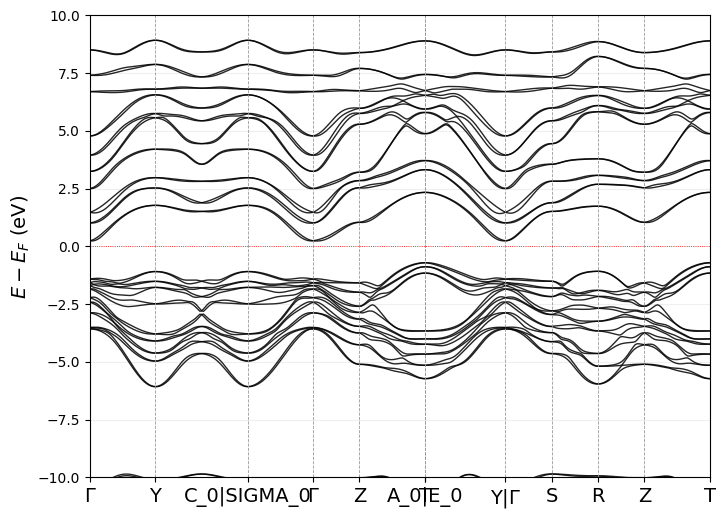

In [7]:
#Plot band structure using SeeKPath
fig = bulk_band_structure(model, auto=True, structure=structure,
                          spacing=0.02, e_range=(-10, 10))
fig

Isolate bands in the vicinty of the Fermi energy to expedite post-processing.
Note that energy range is defined for model prior to alignment to VBM

In [ ]:
from tailwater import subspace_projection
subspace_projection(
    start_lr          = 1e-2,
    end_lr            = 1e-6,
    num_epochs        = 200,
    energy_range      = (-8.0, 10),       # eV, relative to E_F
    decay_sigma       = 6.0,
    device            = "cpu",
    save_path         = "./projection_out",
    embed_path        = paths["embeddings"],
    graph_output_path = paths["graph_output"],
    loss_mode         = "subspace",         # default
)

[bands] path total length = 6.6923  -> N_path = 335 samples (spacing = 0.02)


Band structure: 100%|██████████| 335/335 [00:00<00:00, 1748.98it/s]


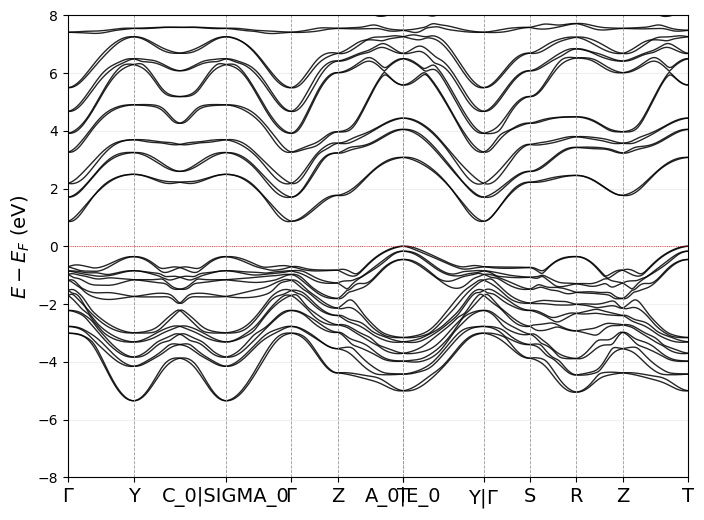

In [10]:
#Load reduced Model and plot band structure
model = tb_model.load("projection_out/embeddings_pred.hdf5")
model     = align_to_vbm(model)
fig = bulk_band_structure(model, auto=True, structure=structure,
                          spacing=0.02, e_range=(-8, 8))
fig

Now we move on to examining the surfaces of KTaO3. The surface have been the study of numerous works (Nat Commun 14, 951 (2023); arXiv:2411.09161; Appl. Phys. Lett. 124, 093102 (2024); Adv. Electron. Mater.2019, 5, 1800860 ) as they support a 2D electron gas similar to that of STO. The surface states are generally analyzed via the recursive Greens Function method in WannierTools (see Adv. Electron. Mater.2019, 5, 1800860 & arXiv:2411.09161). It is important to note that we are interested in surface perpendicular to the princpial axis (001) but also the (1$\bar{1}$1) and (111) surfaces. These surface require rotation of the Hamiltonian into a new coordinate frame. Finally, as the surface states arise in KTaO3 due to oxygen vacancies forming a potential well on the surface, an onsite potential must be added to the surface to accurately model the surface states. This is accomplished via the 'delta' flag under the "SurfaceGreensFunction" method provided by Tailwater. Here we provide examples looking at all three surfaces.  

(001) surface:

In [ ]:
model  = tb_model.load('projection_out/embeddings_pred.hdf5')
result = SurfaceGreensFunction(
    model, surface=np.eye(3),
    energies=np.linspace(-1, 1, 201),
    N_path=51,
    delta=-1,
    device='cuda',
    k_path=[[0, 0.5, 0], [0, 0, 0], [0.5, 0.5, 0]],
    k_labels=["Y", r"$\Gamma$", "M"]
).run()

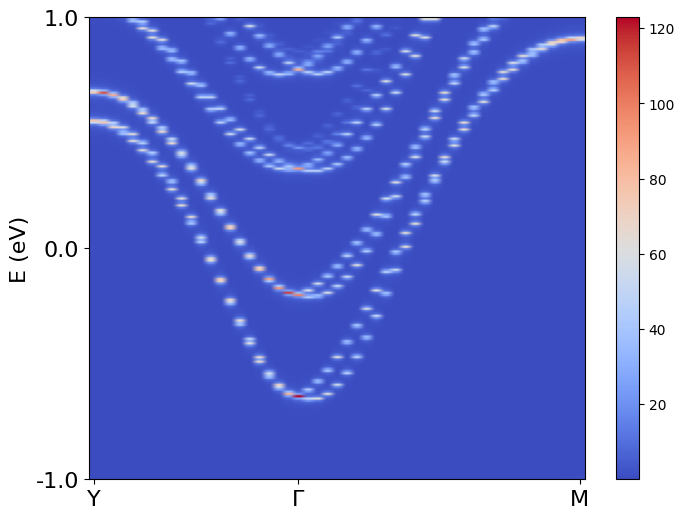

In [28]:
result.figure_top

(110) surface:

In [ ]:
model  = tb_model.load('projection_out/embeddings_pred.hdf5')
result = SurfaceGreensFunction(
    model, surface=np.array([[1,-1,0],[0,0,1],[1,1,0]]),
    energies=np.linspace(-1, 1, 201),
    N_path=51,
    delta=-0.5,
    device='cuda',
    k_path=[[0, 0.5, 0], [0, 0, 0], [0.5, 0.5, 0]],
    k_labels=["Y", r"$\Gamma$", "M"]
).run()

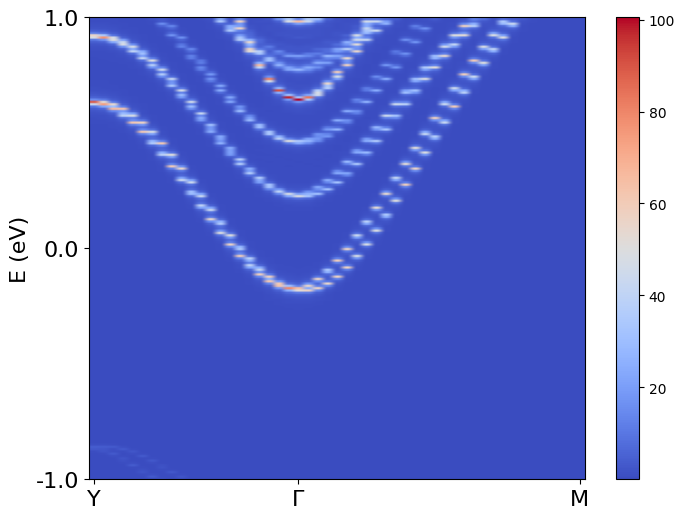

In [43]:
result.figure_top

(111) surface:

In [ ]:
model  = tb_model.load('projection_out/embeddings_pred.hdf5')
result = SurfaceGreensFunction(
    model, surface=np.array([[1,-1,0],[1,1,-2],[1,1,1]]),
    energies=np.linspace(-1, 1, 201),
    N_path=51,
    delta=-0.5,
    device='cuda',
    k_path=[[0, 0.5, 0], [0, 0, 0], [0.333, 0.333, 0]],
    k_labels=["M", r"$\Gamma$", "K"]
).run()

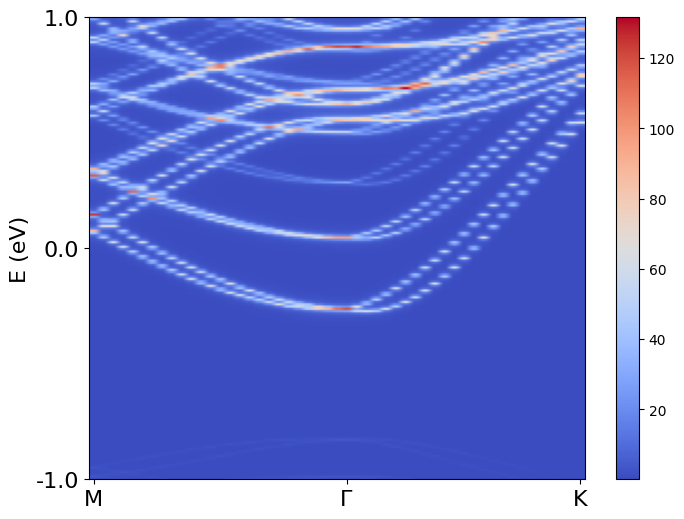

In [15]:
result.figure_top